### Part 0: starting up workload

In [2]:
print("HI")

HI


In [1]:
# from loaders import answer, AnswerMe
from numbers import Number
from typing import List
import matplotlib.pyplot as plt
from IPython.display import display, Math
import accelforge as af
from accelforge.mapper import Metrics
import matplotlib.pyplot as plt

# with open("./specs/fc.workload.yaml") as f:
# 	print(f.read())

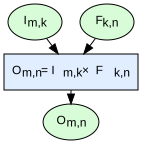

In [4]:
spec = af.spec.Spec.from_yaml(
	"./specs/fc.workload.yaml"
)
spec.workload

In [28]:
with open("./specs/simple.arch.yaml") as f:
	print(f.read())

arch:
  nodes:
  - !Memory
    name: DRAM
    component_class: LPDDR4
    size: inf
    total_latency: (read_actions + write_actions)/(200e9)  # equivalent to 200 Gb/s bandwidth
    tensors:
      keep: All
    extra_attributes_for_component_model:
      width: 64

  - !Memory
    name: OnchipBuffer
    size: 1024*1024 # size in bits
    total_latency: (read_actions + write_actions)/64e12  # equivalent to 64 Tb/s bandwidth
    area: 0  # we are not modeling area
    leak_power: 0 # we are not modeling leakage
    tensors:
      keep: All
    actions:
    - name: read
      energy: 5
      latency: 0
    - name: write
      energy: 5
      latency: 0

  - !Compute
    name: MAC
    area: 0  # we are not modeling area
    leak_power: 0 # we are not modeling leakage
    spatial:
    - name: ComputeArrayX
      fanout: 32
      loop_bounds:
      - expression: c
        operator: ==
        value: 32
      - expression: m
        operator: ==
        value: 1
      - expression: p
        

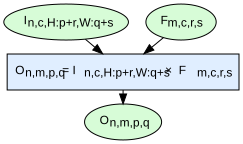

In [29]:
spec = af.Spec.from_yaml(
    "./specs/conv.workload.yaml",
    jinja_parse_data={"N": 1}
)
spec.workload

In [30]:
def conv_ops(input_shape: dict[str, int], filter_shape: dict[str, int]) -> int:
    """
    Calculates the amount of multiplications in a convolutional layer.

    Parameters
    ----------
    input_shape:
            Input shape, which has keys "N", "C", "H", "W".
    filter_shape:
            Filter weight shape, which has keys "M", "C", "R", "S".

    Returns
    -------
    The number of multiplications in the convolution.
    """
    # Rank shapes
    N = input_shape["N"]
    H = input_shape["H"]
    W = input_shape["W"]
    R = filter_shape["R"]
    S = filter_shape["S"]
    P: int = (H - R) + 1
    Q: int = (W - S) + 1
    C = filter_shape["C"]
    M = filter_shape["M"]

    # raise NotImplementedError("conv_ops is not implemented.")
    ########################
    #### YOUR CODE HERE ####
    ########################
    return N * M * P * Q * C * R * S


def min_conv_data_movement(
    input_shape: dict[str, int],
    filter_shape: dict[str, int],
) -> int:
    """
    Return the total number of reads and writes from/to off-chip memory (in
    number of tensor elements) assuming each tensor is only read/written once.

    In your implementation, consider only reads of tensors I, F, and writes of tensor O.

    Parameters
    ----------
    input_shape:
            Dictionary of the size of each rank of the input.
    filter_shape:
            Dictionary of the size of each rank of the filter.
    """
    # Rank shapes
    N = input_shape["N"]
    H = input_shape["H"]
    W = input_shape["W"]
    R = filter_shape["R"]
    S = filter_shape["S"]
    P = (H - R) + 1
    Q = (W - S) + 1
    C = filter_shape["C"]
    M = filter_shape["M"]

    ########################
    #### YOUR CODE HERE ####
    ########################
    # raise NotImplementedError("please complete the rest of the function")
    return N*C*H*W + C*M*R*S + N*M*P*Q

def roofline_transition(
    peak_computational_throughput: Number, bandwidth: Number
) -> Number:
    """
    Return the computational intensity (in ops/tensor-element) when the
    processing turns from bandwidth- to compute-bound.

    Parameters
    ----------
    peak_computational_throughput:
        Peak computational throughput in ops/cycle
    bandwidth:
        Memory bandwidth in tensor-element/cycle
    """
    # raise NotImplementedError("not implemented")
    ########################
    #### YOUR CODE HERE ####
    ########################
    return peak_computational_throughput/bandwidth

In [31]:
# Assume a convolutional layer with the following shape
# input_shape = {"N": 4, "C": 64, "H": 24, "W": 24}

# filter_shape = {"C": 64, "M": 128, "R": 3, "S": 3}

# throughput = 8*1024 # 8,192 ops/cycle
# bandwidth = 25      # 25 tensor-element/cycle

# computational_intensities = []
# actual_throughputs = []
# for N in [1, 2, 4, 8, 16, 32]:
#     input_shape["N"] = N
#     spec = af.Spec.from_yaml(
#         "./specs/conv.workload.yaml",
#         "./specs/simple.arch.yaml",
#         jinja_parse_data={"N": N}
#     )
#     spec.mapper.metrics = Metrics.LATENCY
#     mapping_result = af.mapper.FFM.map_workload_to_arch(spec)
#     num_conv_ops = conv_ops(input_shape, filter_shape) # TODO implement...
#     latency = mapping_result["Total<SEP>latency"].min()*1e9
#     actual_throughput = num_conv_ops/latency
#     actual_throughputs.append(actual_throughput)
#     data_movement = min_conv_data_movement(input_shape, filter_shape)
#     computational_intensity = num_conv_ops/data_movement
#     computational_intensities.append(computational_intensity)

# import matplotlib.pyplot as plt

# fig, ax = plt.subplots()

# ax.scatter(computational_intensities, actual_throughputs)

# MIN_CI = 200
# MAX_CI = 380
# ax.plot(
#     [MIN_CI, roofline_transition(throughput, bandwidth)],
#     [MIN_CI*bandwidth, throughput],
#     label="Bandwidth-bound"
# )
# ax.plot(
#     [roofline_transition(throughput, bandwidth), MAX_CI],
#     [throughput, throughput],
#     label="Compute-bound"
# )
# ax.set_xlabel("Computational intensity (ops/tensor-element)")
# ax.set_ylabel("Actual computational throughput (ops/cycle)")
# ax.legend()

### Part 1: RAG workload

In [32]:
with open("./specs/gpt175B.yaml") as f:
	# print(f.read())
    print("opened")

opened


In [33]:
spec = af.Spec.from_yaml(
    "./specs/gpt175B.yaml",
    jinja_parse_data={}
)
# spec.workload
rank_sizes = spec.workload.rank_sizes


In [34]:
spec = af.Spec.from_yaml(
    "./specs/rag.yaml",
    jinja_parse_data={}
)

rank_sizes = spec.workload.rank_sizes
for einsum in spec.workload.einsums:
    # get all ranks involved in this einsum
    ranks = einsum.ranks  # or .rank_set, .dimensions — check via print(dir(einsum))
    complexity = 1
    for r in ranks:
        complexity *= rank_sizes[r]
    print(f"{einsum.name}: {complexity} ops  (ranks: {ranks})")

X: 12582912000 ops  (ranks: oset({'D', 'T', 'V'}))
Q: 301989888 ops  (ranks: oset({'D', 'DK', 'T'}))
K: 301989888 ops  (ranks: oset({'D', 'DK', 'T'}))
V: 301989888 ops  (ranks: oset({'D', 'DV', 'T'}))
A: 201326592 ops  (ranks: oset({'DK', 'S', 'T'}))
P: 262144 ops  (ranks: oset({'S', 'T'}))
H: 201326592 ops  (ranks: oset({'DV', 'S', 'T'}))
Z_Q: 393216 ops  (ranks: oset({'DV', 'T'}))
S_score: 786432 ops  (ranks: oset({'DV', 'N'}))
TK: 524288 ops  (ranks: oset({'N', 'T'}))


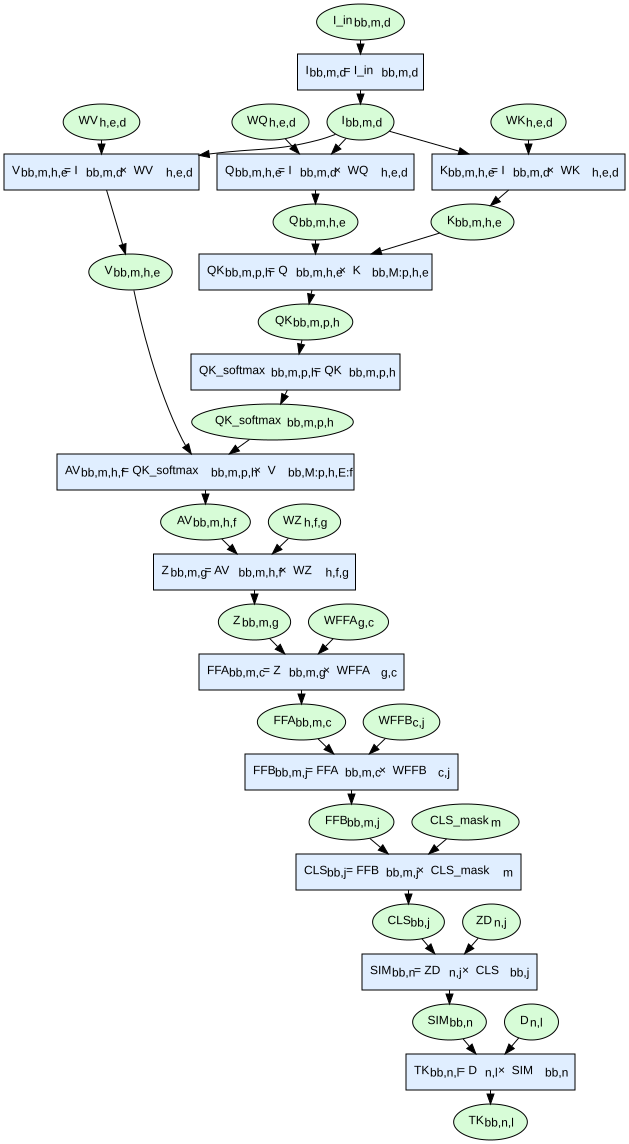

In [35]:
spec = af.Spec.from_yaml(
    "./specs/bert_rag.yaml",
    jinja_parse_data={}
)
spec.workload


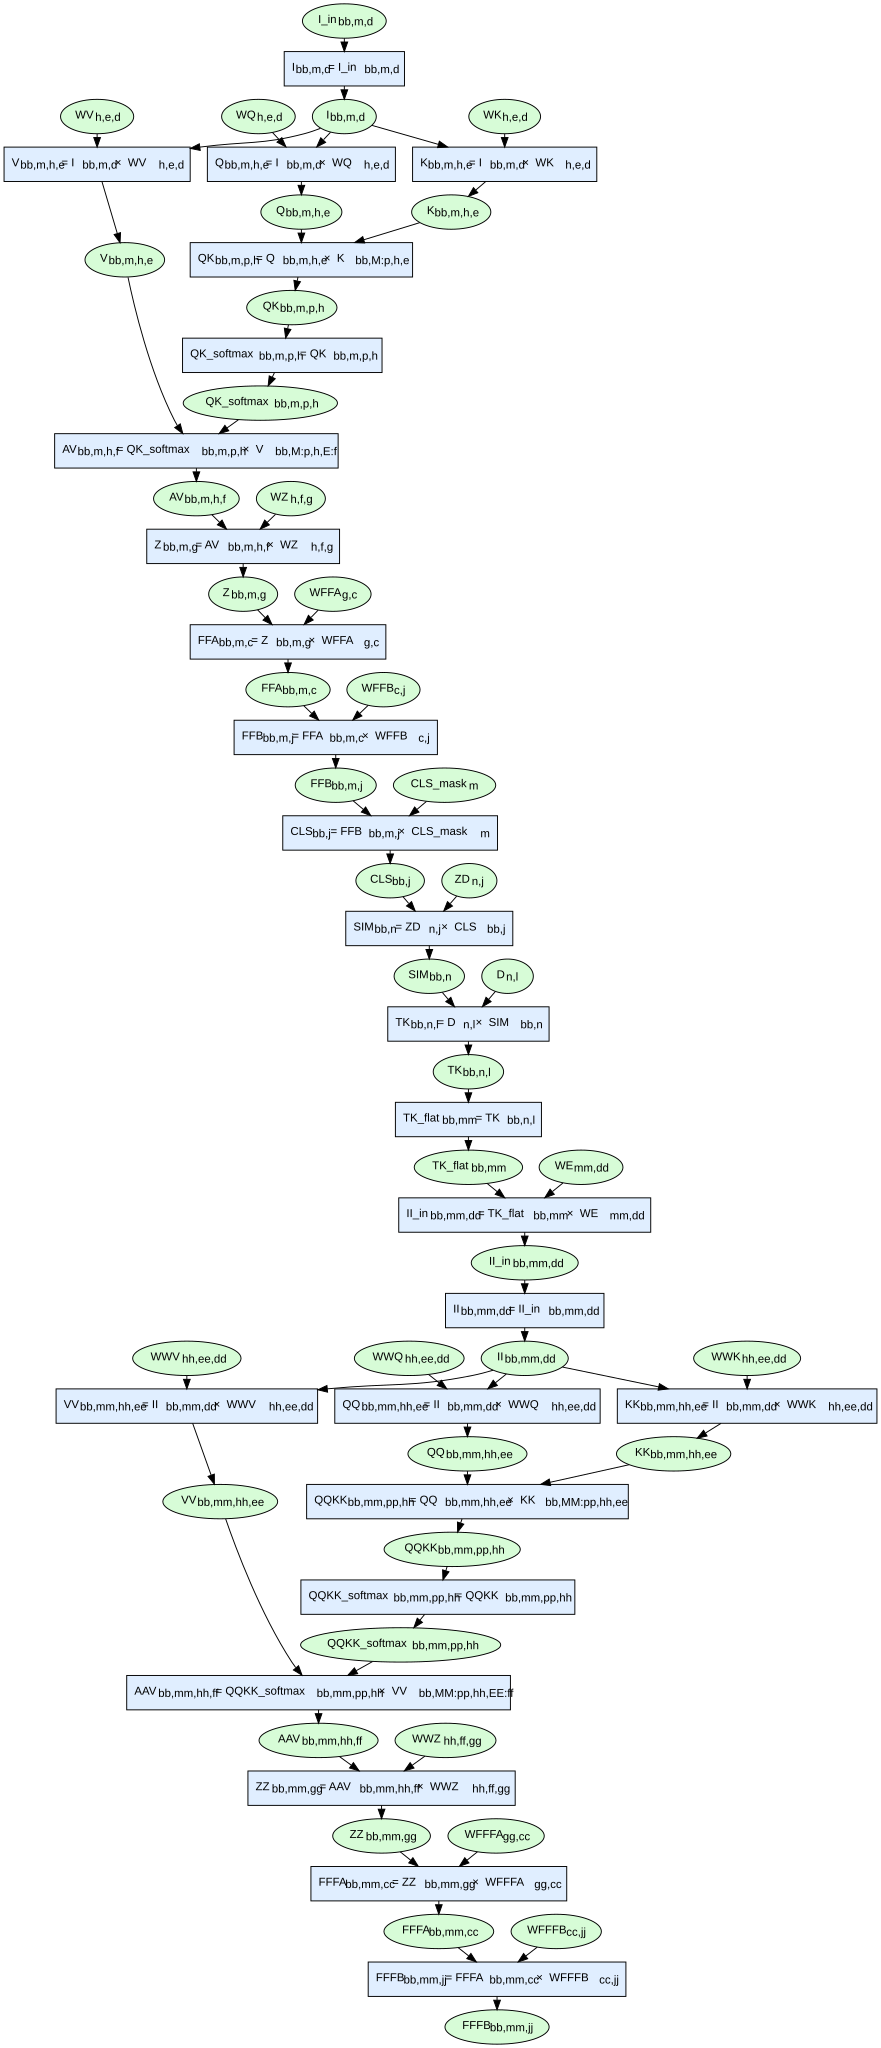

In [37]:
spec = af.Spec.from_yaml(
    "./specs/full.yaml",
    jinja_parse_data={}
)
spec.workload

In [14]:
print("TODO")

TODO


### Part 2: Analysis
Analyze the mappings and energy breakdown, and report energy or latency bottlenecks.
Which architectural components are bottlenecks? For which workload configurations?
Which Einsums in the workload cause these bottlenecks?

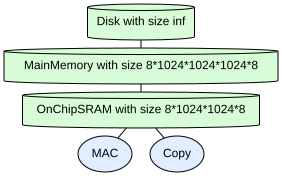

In [8]:
spec = af.Spec.from_yaml(
    "specs/basic8.yaml",
    "specs/gpt175B.yaml",
    jinja_parse_data={}
)
spec.arch

In [9]:
if spec.workload:
    print("ok")

ok


In [12]:
# mappings = spec.map_workload_to_arch()
pass

In [ ]:
mappings.energy(per_component=True, per_action=True)

In [ ]:
mappings.latency(per_component=True)

In [ ]:
spec.mapper.metrics = Metrics.LATENCY | Metrics.ENERGY
area = spec.calculate_component_area_energy_latency_leak().arch.total_area
print("Your area is", area) 

mappings = spec.map_workload_to_arch()
edp = (mappings.data["Total<SEP>energy"], mappings.data["Total<SEP>latency"])
print(edp)

In [15]:
WORKLOAD_PATH = "specs/full.yaml",

workload = af.Workload.from_yaml(
    WORKLOAD_PATH,
    top_key='workload',
    jinja_parse_data={},
)
# renames = af.Renames.from_yaml(
#     WORKLOAD_PATH,
#     top_key='renames',
#     jinja_parse_data={},
# )

print(f'Loaded {len(workload.einsums)} einsums:')
for e in workload.einsums:
    print(f'  {e.name}')

Loaded 25 einsums:
  I
  V
  K
  Q
  QK
  QK_softmax
  AV
  Z
  FFA
  FFB
  CLS
  SIM
  TK
  TK_flat
  II_in
  II
  VV
  KK
  QQ
  QQKK
  QQKK_softmax
  AAV
  ZZ
  FFFA
  FFFB


ok


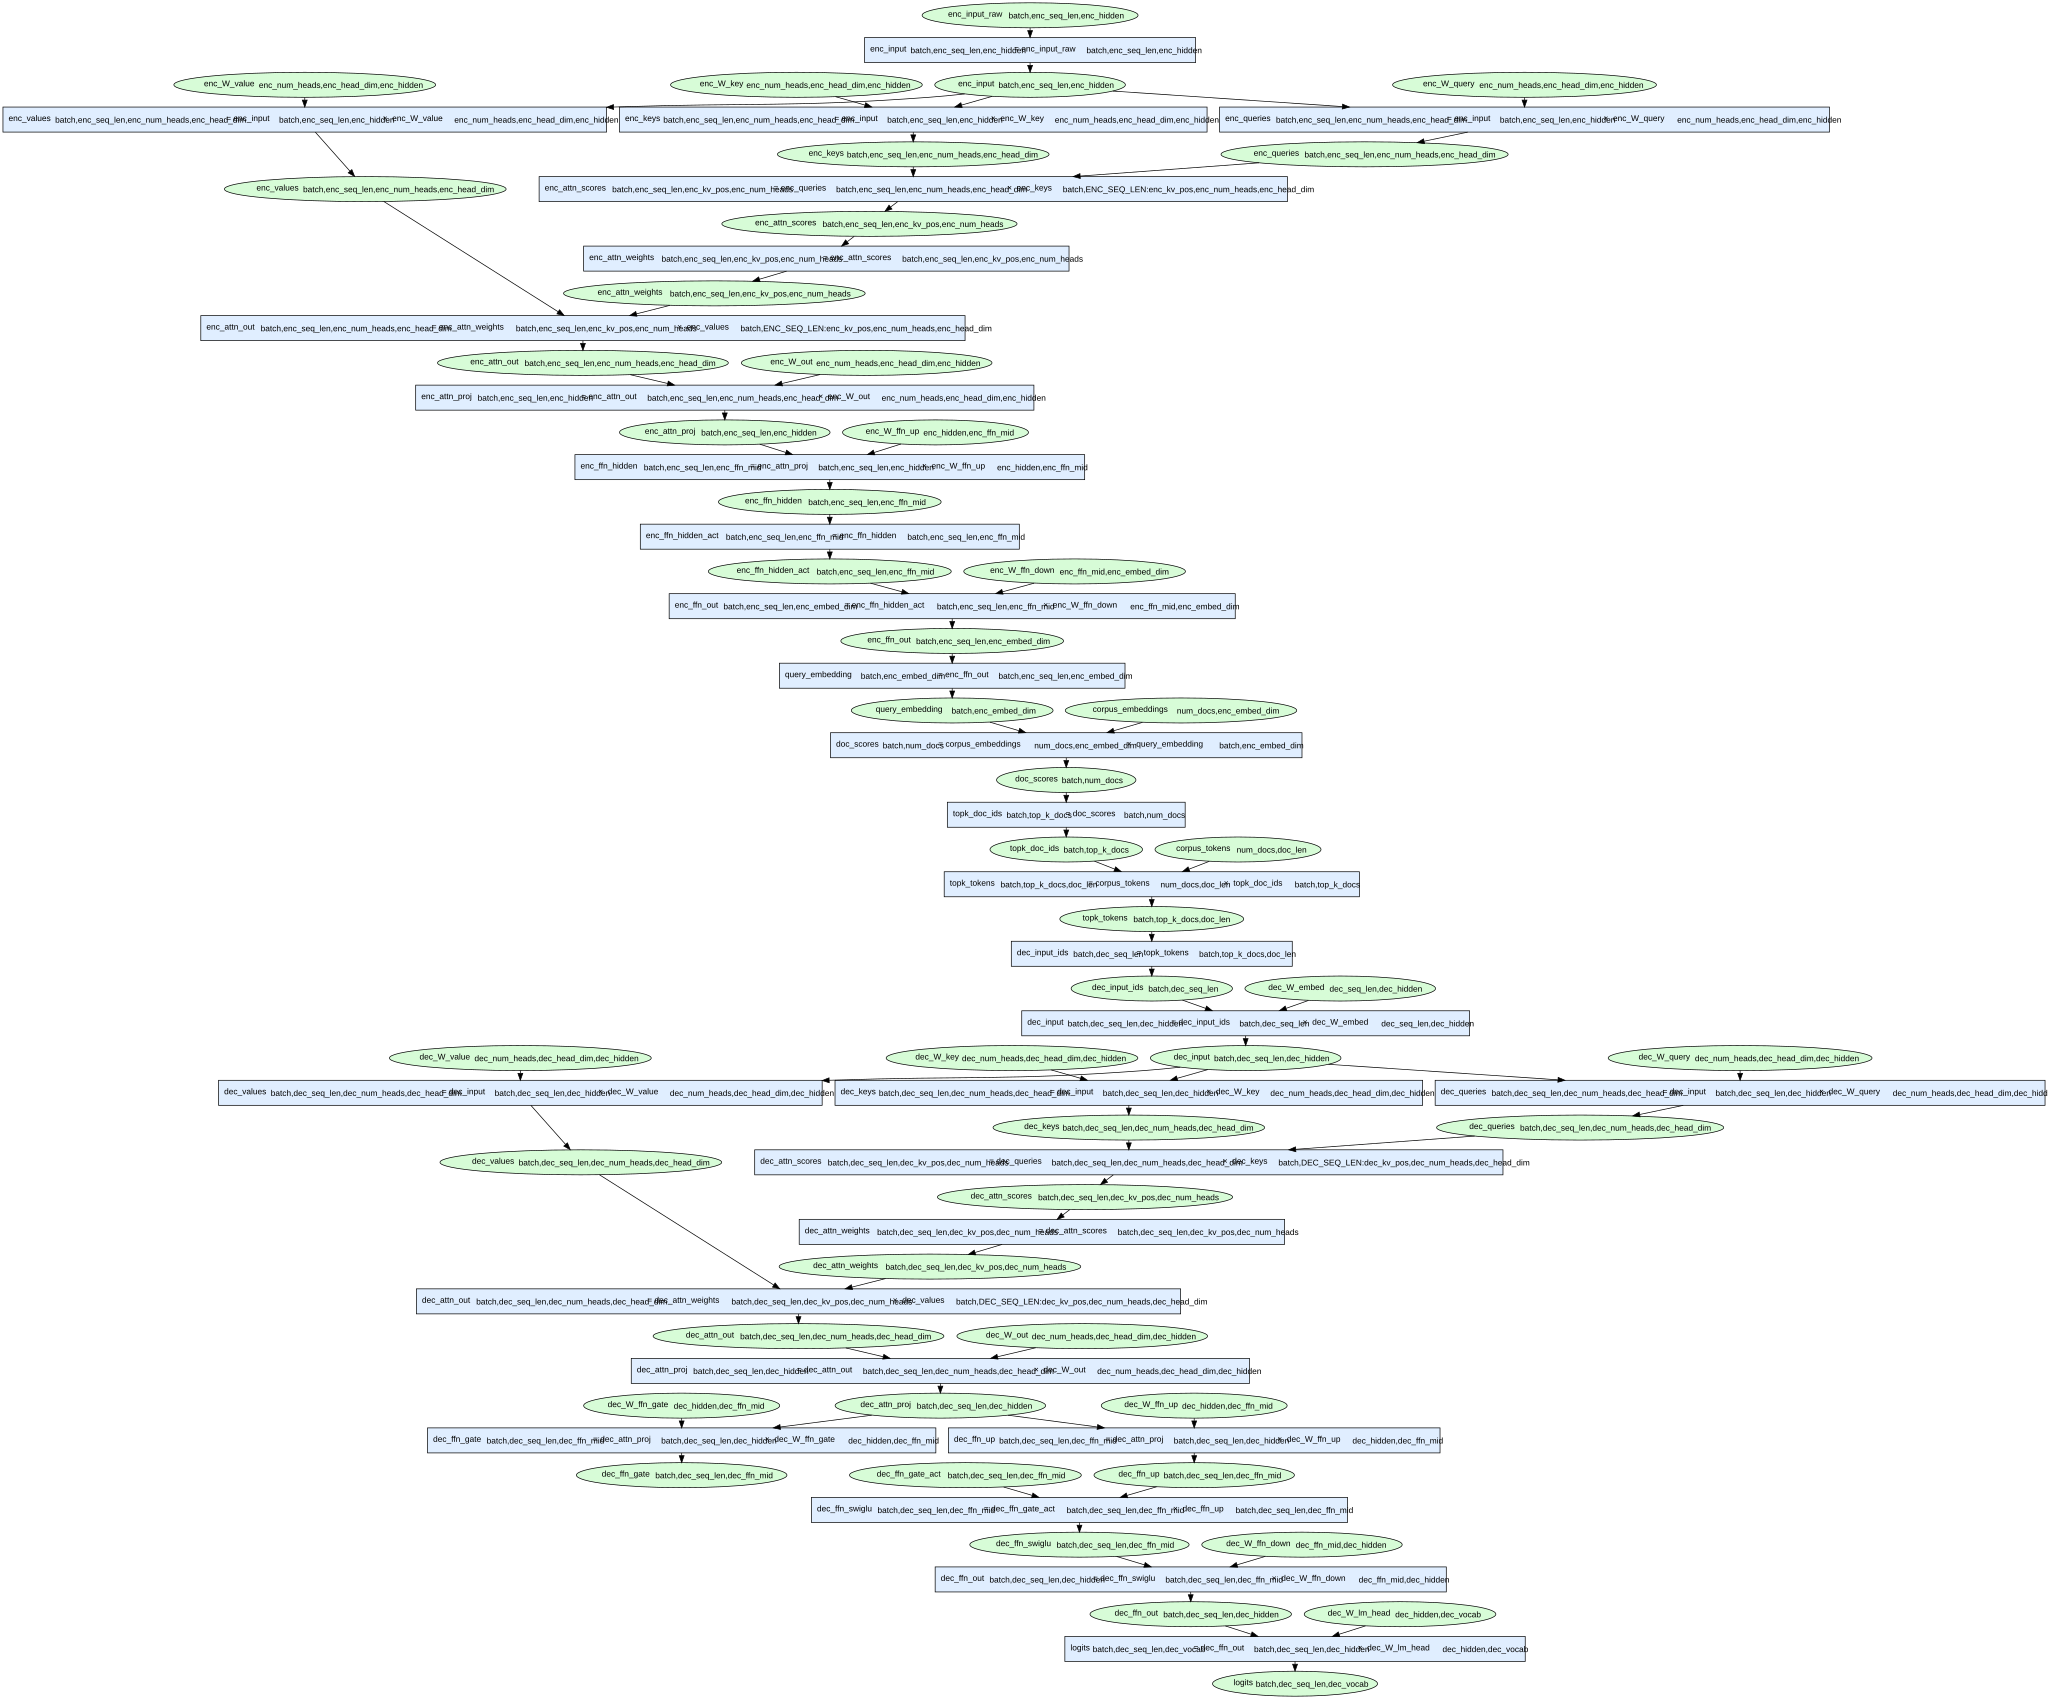

In [10]:
spec = af.Spec.from_yaml(
    "./workload/full_EdgeRAG.yaml",
    jinja_parse_data={}
)
print("ok")
spec.workload